In this notebook, you will learn to analyze the multineuron spiking activity of neurons in the mouse hippocampus from the Schnitzer lab.


# Download the data

(1) Download the datafile called `hippocampal_neurons.npy` and `mouse_position,npy` from elearning to your computer.

(2) Run the code cell below. It will open a file picker GUI using which you can manually select and load both `npy` datafiles by clicking `Choose Files` and navigating to the folder to which you downloaded the files. You should see the file being loaded in google colab. You're all set to move on!

In [24]:
from google.colab import files
uploaded = files.upload()

Saving hippocampal_neurons.npy to hippocampal_neurons (1).npy
Saving mouse_position.npy to mouse_position (1).npy


In [25]:
import numpy as np
from matplotlib import pyplot as plt
response = np.load('hippocampal_neurons.npy', allow_pickle=True)
position = np.load('mouse_position.npy')

Get familiar with the type and shape of the data arrays

In [26]:
# response variable
print('response type: ', type(response))  # Type of Variable
print('response dtype: ', response.dtype) # Data Type (int32, float64, bool, etc.)
print('response shape: ', response.shape) # Shape of Array in Rows x Co`lunmns
# position variable
print('position type: ', type(position))
print('position type: ', position.dtype)
print('position type: ', position.shape)

response type:  <class 'numpy.ndarray'>
response dtype:  float32
response shape:  (36078, 188)
position type:  <class 'numpy.ndarray'>
position type:  float32
position type:  (36078,)


Create useful variables for later use

In [ ]:
[n_timepoints, n_neurons] = np.shape(response) # number of time points and neurons because response is a 2D array of shape (n_timepoints, n_neurons)
pos_min, pos_max = np.nanmin(position), np.nanmax(position) #namin ignores missing values
n_bins = 25           # number of spatial bins

Plot the tuning function of a random neuron

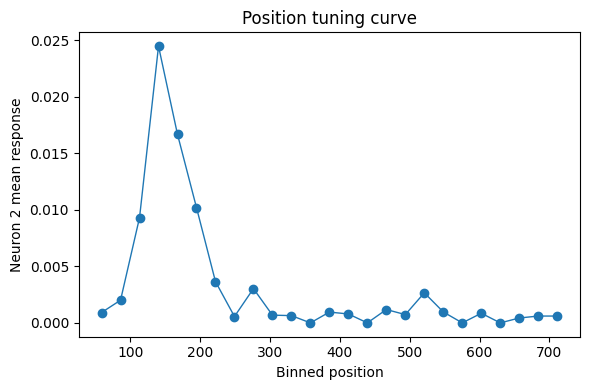

In [28]:
# Pick a neuron
neuron_idx = np.random.randint(n_neurons) #Random integer between 0 and whatver variable/number you put in the ()
r = response[:, neuron_idx] #Picks one column

# Bin position
edges = np.linspace(pos_min, pos_max, n_bins + 1) #Edges of the different bins, linspace: Linearly spaced list of points, set of numbers of equally spaced numbers from the initial argument to the 2nd argument (max) and how 3rd argument how many numbers you actually want.
centers = 0.5 * (edges[:-1] + edges[1:]) #Store the centers of the edges, plotting the neural response as a function of which bin it is.

# Assign each timepoint to a bin
bin_idx = np.digitize(position, edges) - 1  # 0, 1, ..., n_bins-1 | Digitize, takes position (continous), digitizes it using edges.
validbins = (bin_idx >= 0) & (bin_idx < n_bins)
bin_idx = bin_idx[validbins]
r_valid = r[validbins]

# Compute mean response per bin (tuning curve)
sum_r = np.bincount(bin_idx, weights=r_valid, minlength=n_bins)
cnt = np.bincount(bin_idx, minlength=n_bins)
mean_r = sum_r / cnt

# Plot
plt.figure(figsize=(6, 4))
plt.plot(centers, mean_r, marker='o', linewidth=1)
plt.xlabel('Binned position')
plt.ylabel(f'Neuron {neuron_idx} mean response')
plt.title('Position tuning curve')
plt.tight_layout()
plt.show()

Plot the tuning function of all neurons as a heatmap

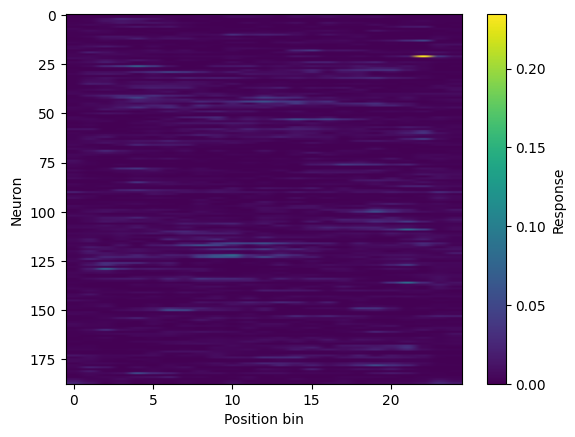

In [29]:
# Bin position
edges = np.linspace(pos_min, pos_max, n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
bin_idx = np.digitize(position, edges) - 1  # 0..n_bins-1
validbins = (bin_idx >= 0) & (bin_idx < n_bins)
bin_idx = bin_idx[validbins]
tuning = np.zeros((n_neurons, n_bins))

for neuron_idx in np.arange(0, n_neurons):

  # Pick a neuron
  r = response[:, neuron_idx]

  # Assign each timepoint to a bin
  r_valid = r[validbins]

  # Compute mean response per bin (tuning curve)
  sum_r = np.bincount(bin_idx, weights=r_valid, minlength=n_bins)
  cnt = np.bincount(bin_idx, minlength=n_bins)
  tuning[neuron_idx] = sum_r / cnt

plt.imshow(tuning, aspect='auto') #2D Array
plt.xlabel('Position bin')
plt.ylabel('Neuron')
plt.colorbar(label='Response')

Why does it look uninteresting? Try dividing each row by the highest entry before plotting i.e., normalize the response of each neuron.

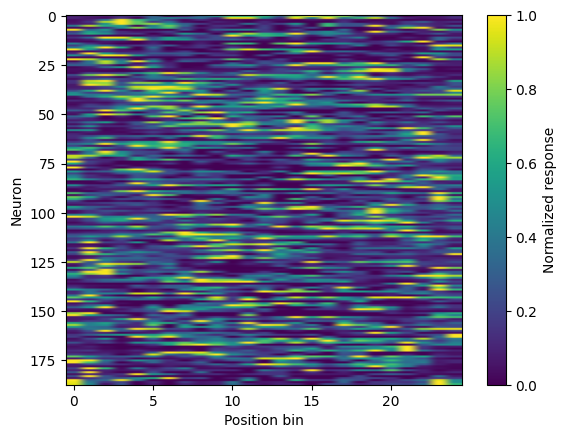

In [30]:
row_max = tuning.max(axis=1, keepdims=True)
tuning_normalized = tuning / row_max

plt.imshow(tuning_normalized, aspect='auto')
plt.xlabel('Position bin')
plt.ylabel('Neuron')
plt.colorbar(label='Normalized response')

Still looks uninteresting? Try sorting the rows based the position bin with the highest response i.e, rearrange neurons based on their spatial preference.

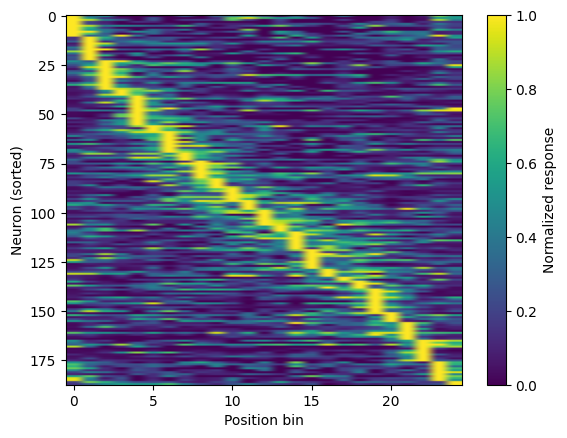

In [31]:
pref_bin = np.nanargmax(tuning_normalized, axis=1)
order = np.argsort(pref_bin)
tuning_sorted = tuning_normalized[order]
plt.imshow(tuning_sorted, aspect='auto')
plt.xlabel('Position bin')
plt.ylabel('Neuron (sorted)')
plt.colorbar(label='Normalized response')
plt.show()

So far, we have just applied univariate analysis to every single neuron. Let us now estimate the response covariance between pairs of neurons across position bins.

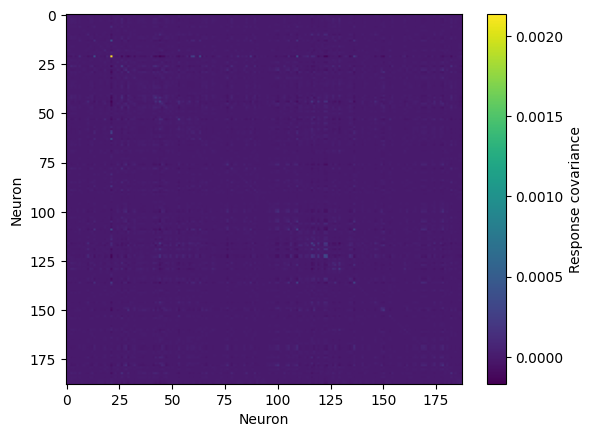

In [32]:
C_tuning = np.cov(tuning)
plt.imshow(C_tuning, aspect='auto')
plt.xlabel('Neuron')
plt.ylabel('Neuron')
plt.colorbar(label='Response covariance')

Looks like we are running into a similar problem. Let's try to work with the normalized, sorted responses

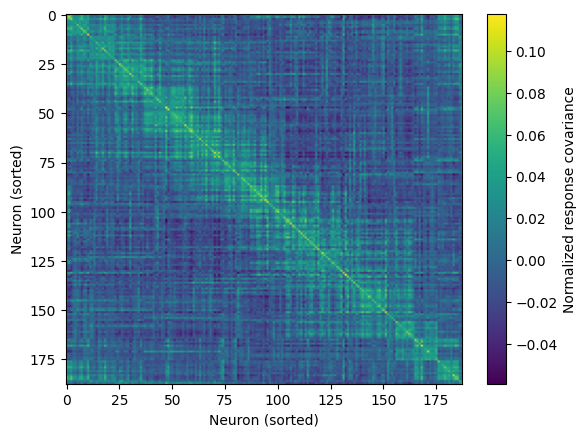

In [33]:
C_tuning = np.cov(tuning_sorted)
plt.imshow(C_tuning, aspect='auto')
plt.xlabel('Neuron (sorted)')
plt.ylabel('Neuron (sorted)')
plt.colorbar(label='Normalized response covariance')

Looks like there is some structure in the data. Let's apply principal component analysis to see if we can extract that structure.

In [34]:
from sklearn.decomposition import PCA

pca = PCA()
scores = pca.fit_transform(tuning_sorted.T)       # neuron coordinates in PC space
components = pca.components_                    # spatial modes

That's it! You have now extracted the principal components. Let's plot the first few principal components. To plot the first principal component, we need to project the data onto the direction corresponding to the first principal component. `pca.fit_transform` function above already did that for us for every component, so we can just plot the `scores`.

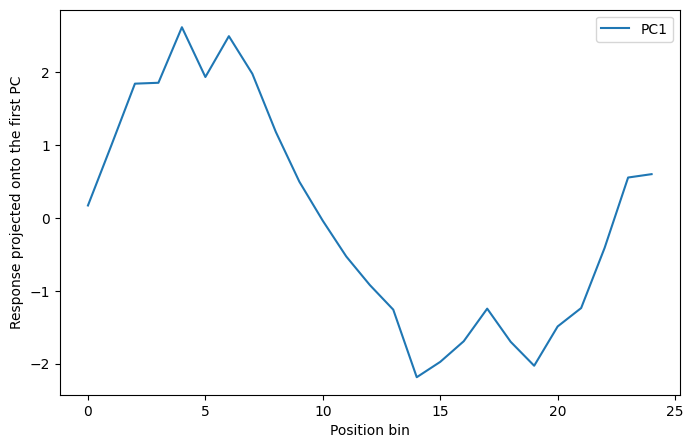

In [35]:
plt.figure(figsize=(8,5))
plt.plot(scores[:, 0], label=f"PC{1}")
plt.xlabel('Position bin')
plt.ylabel('Response projected onto the first PC')
plt.legend()
plt.show()

Let's look at the first 5 PCs

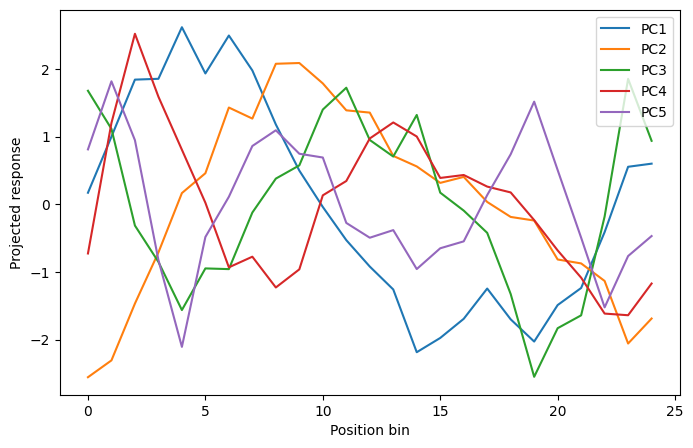

In [36]:
plt.figure(figsize=(8,5))
for k in range(5):
    plt.plot(scores[:, k], label=f"PC{k+1}")
plt.xlabel('Position bin')
plt.ylabel('Projected response')
plt.legend()
plt.show()

How about the first 10 PCs? What do you observe?

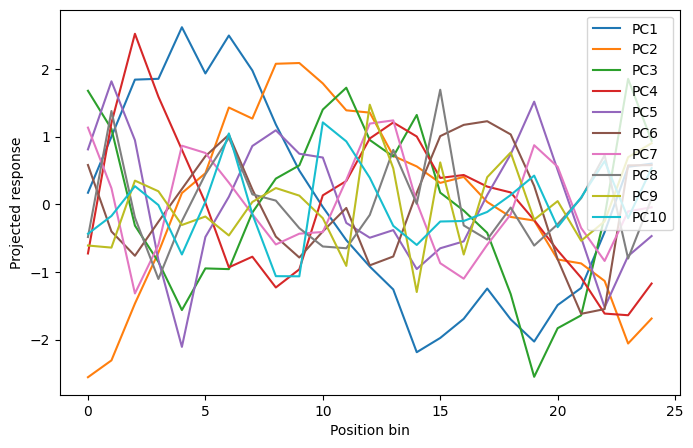

In [37]:
plt.figure(figsize=(8,5))
for k in range(10):
    plt.plot(scores[:, k], label=f"PC{k+1}")
plt.xlabel('Position bin')
plt.ylabel('Projected response')
plt.legend()
plt.show()

Let's take a look at how much variance i.e., spread in the data is explained by each principal component.

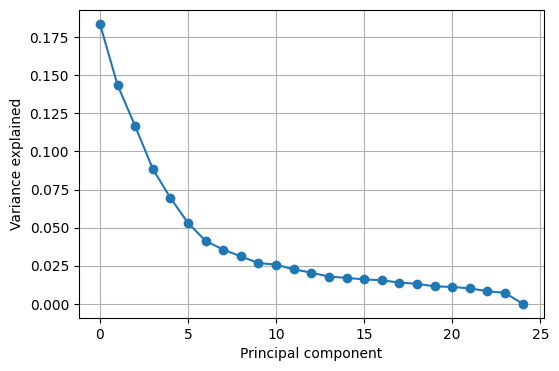

In [38]:
# Variance explained
varexp = pca.explained_variance_ratio_

# Plot
plt.figure(figsize=(6,4))
plt.plot(varexp, marker='o')
plt.xlabel("Principal component")
plt.ylabel("Variance explained")
plt.grid(True)
plt.show()

It is often useful to plot the cumulative variance explained before deciding which principal components to keep and which ones to discard.

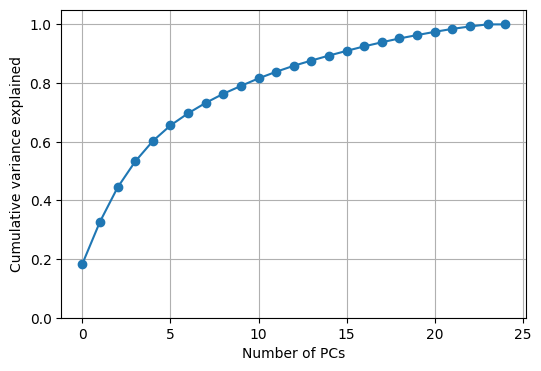

In [39]:

# Cumulative variance explained
cumvar = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(6,4))
plt.plot(cumvar, marker='o')
plt.xlabel('Number of PCs')
plt.ylabel('Cumulative variance explained')
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

Looks like the top 10 principal components collectively explain more than 80% variance. Let's discard the rest and try to reconstruct the original data from the top 10 principal components

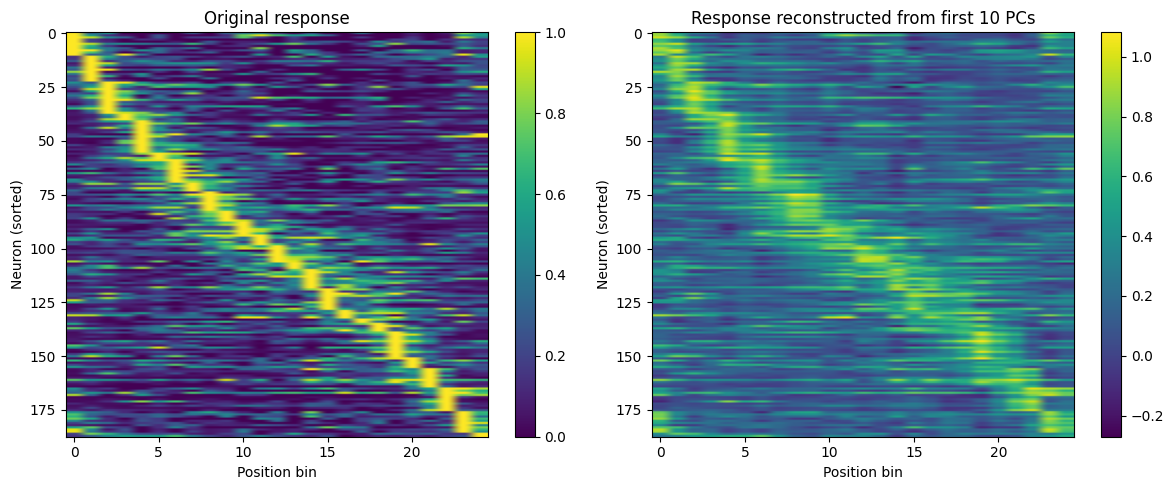

In [40]:

pca = PCA(n_components=10)
scores = pca.fit_transform(tuning_sorted.T)
tuning_sorted_hat = pca.inverse_transform(scores)
tuning_sorted_hat = tuning_sorted_hat.T

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12,5))

im0 = axes[0].imshow(tuning_sorted, aspect='auto')
axes[0].set_title('Original response')
axes[0].set_xlabel('Position bin')
axes[0].set_ylabel('Neuron (sorted)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(tuning_sorted_hat, aspect='auto')
axes[1].set_title('Response reconstructed from first 10 PCs')
axes[1].set_xlabel('Position bin')
axes[1].set_ylabel('Neuron (sorted)')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()